## AY25-26 Term 2 CS421 Group Project

### Data and Task

In this project, you will be working with data extracted from a recommender systems type dataset: you are provided with a large set of interactions between subjects (e.g., online shopping users, or social network users)  and items (e.g., shopping items, books, songs, or movies). Whenever a user "interacts" with an item, he/she has some experience the item (e.g., purchase the items, read the book, listen the songs, or watch the movie) and gives a mark or "rating" between 0 and 5 stars (5 stars indicating the best experience, and 1 or 0 stars indicating that the user didn't like the experience at all). 




In this exercise, we will **not** be performing the recommendation task per se. Instead, we will identify *anomalous users*. In the dataset that you are provided with, some of the data was corrupted. Whilst most of the data comes from real life user-item interactions from a real-world application, some "users" are anomalous: they were generated by me according to some undisclosed procedure to simulate exceptional users with unexpected interactions. Most users have normal, expected interactions in real applications, so the anomalous users only account for a very small proportion of the users. Thus, identifying those anomalous users are important to the application, but it can be very challenging.

You are provided with two data frames: the first one ("X") contains the interactions provided to you, and the second one ("y") contains the labels for the users. There is a set of 1,000 unique items the users interact with, ranging from item ID of 0 to item ID 999, which is fixed throughout the competition. Note that it is not necessarily that all items appear in one set of data samples given during the competition, meaning that some of the items may not be rated by any user in a user set within a specific period of time.

As you can see, the three columns in "ratings" correspond to the user ID, the item ID and the rating. Thus, each row of "ratings" contains a single interaction. For instance, if the row "142, 152, 5" is present, this means that the user with ID 142 has given the movie 152 the rating 5 stars.

The dataframe "labels" has two columns. In the first column we have the user ids, whilst the second column contains the labels. A label of 1 indicates that the user is 'anomalous', whilst a label of 0 denotes a natural, normal user (coming from real life interactions). 

For instance, if the labels matrix contains the line "142, 1", it means that all of the ratings given by the user with id 142 is an anomalous user. This means all lines in the dataframe "ratings" which start with the userID 142 correspond to fake interactions. 

### Evaluation

Your task is to be able to classify unseen instances as either anomalies or non anomalies. 

There are **far more** normal users than anomalies in the dataset, which makes this a very heavily **unbalanced dataset**. Thus, accuracy will not be a good measure of performance, since simply predicting that every user is normal will give good accuracy. Thus, we need to use some other evaluation metrics (see slides and lecture note from week 3). 

Suitable **EVALUATION METRICS** include: **AUC** (AREA UNDER CURVE), **PRECISION**, **RECALL**, and **F1 score**. The **main metric** will be the **AREA UNDER CURVE**, and it will by default be used to rank teams. This means your programs should return an **anomaly score** for each user (the higher the score, the more likely the model think the sample is anomalous).  

Before Week 9, each team is required to develop a model using the data `training_data_with_labels.npz` that contains labeled data. You can leverage the data in whatever the way you believe is right. Thereafter every week, we will evaluate the performance of each team's model on an *unseen test set* I will provide, in terms of AUC, and rank the teams by **AUC**. We will release the class labels for the test dataset after we finalize the ranking for each week. Each team then can utilize this newly released class labels (together with the previously released labeled data) to develop a better model.

The difficulty implied by **the generation procedure of the anomalies WILL CHANGE as the project evolves: depending on how well the teams are doing, I will generate easier or harder anomalies**.

The **first round of competition** will take place after recess (week 9): this means that I will **release the first test set on the Thursday of week 9**, and you must submit at least one valid set of anomaly scores to **Codabench** before the **Wednesday of week 10 at 11:59 PM**. Your submission will be **a .npz file** (check the exemplar file attached and the code below that generates the .npz file for detail). We will then look at the results together during Thursday's class. Each group will be limited to no more than **THREE submissions per week**. The best result is taken to rank in the leaderboard.  

We will check everyone's performance in this way every week (once on  week 10, once on week 11, and once on week 12). 

Whilst performance (expressed in terms of AUC and your ranking compared to other teams) at **each of the check points** (weeks 9 to 12 inclusive) is an **important component** of your **final grade**, the **project report** and the detail of the various methods you will have tried will **also** be very **important**. Ideally, to get perfect marks (A+) for this component, you should try at least **two supervised methods** and **one unsupervised methods**, as well as be ranked among the **best teams (top 3)** in terms of performance. 

For the project report, I will be especially interested in your analysis and reasoning. High marks will be given to any team that is able to qualitatively and quantitatively analyze the performance of different versions of your models, delivering convincing empirical justification about why the models behave in a particular way. Exemplar qualitative analyses include visualization of feature representations learned in hidden layers, distribution of anomaly scores for the two classes, reasoning over typical failure and correct cases, etc. In terms of quantitative analysis, in addition to general AUC performance of your overall models, other useful quantitative results may include ablation study (i.e., how each component of your model contributes to the overall performance), hyperparameter sensitivity analysis, analysis of computational cost, etc.


The performance part of the grading will be based the leaderboard ranking of your group averaged over the three weeks (50% on the first two rounds of ranking, and 50% on the last round of ranking).

**Leaderboard Instructions**

Create an account on Codabench using your **school email address**. Then, click on the competition link and register for the competition. Once you complete the registration, you will be automatically enrolled in the competition.

**Only one registration per group** is needed; more registration will not be approved, as we rely on the registration to strictly enforce the THREE submissions per week.

**Submision Format**
1. Save your predictions as a .npz file
   The key **must** be named `predictions`, otherwise the scoring program will not be able to read your submission.
   
2. Zip the file
eg. "submission.npz"  →  "submission.zip"

3. Upload "submission.zip" to Codabench

Competition link : https://www.codabench.org/competitions/14096/

**There's limit on the number of submissions allowed per day and per competition phase, so plan you submissions carefully.

**Phases**
1. **Trial Phase.** From now until Wednesday 11.59pm Week 9. Training data is `training_data_with_labels.npz`. Toy test data: `subset_training_batch.npz`, on which you can make prediction and submit the prediction scores. It is for you to get familiar with Codabench.

2. **Competition Phases.** Each week we release a new test set at Codabench on Thursday (first release will be at week 9).
- Each group must submit at least one valid set of anomaly scores to Codabench before the Wednesday of subsequent week at 11:59 PM. Your group's ranking will be zero if otherwise.
- AUC performance of your submitted anomaly scores will be used for leaderboard ranking.
- The class labels for the test data will be released on `eLearn -> CS421 -> Content -> Group Project` for better training the model for next round
- Up to **THREE** submissions per week per group.

In [1]:
# MAKE SURE TO RUN THIS CELL ONCE ONLY
import os
from dotenv import load_dotenv

# Walk up directories until we find .env
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, ".env")):
        PROJECT_ROOT = _dir
        break
    _dir = os.path.dirname(_dir)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))

ORIGINAL_MATS_DIR = os.path.join(PROJECT_ROOT, os.getenv("ORIGINAL_MATS_DIR"))
WEIGHTS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("WEIGHTS_DIR_LARRY"))
GRAPHS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("GRAPHS_DIR_LARRY"))
RESULTS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("RESULTS_DIR_LARRY"))

train_0_1_path = os.path.join(ORIGINAL_MATS_DIR, "Labelled_0_1_2.npz")
infer_data_path = os.path.join(ORIGINAL_MATS_DIR, "third_batch.npz")

print("train_data_path:", train_0_1_path)
print("tests_data_path:", infer_data_path)

train_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\Labelled_0_1_2.npz
tests_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\third_batch.npz


In [2]:
import numpy as np
import pandas as pd

data = np.load(train_0_1_path)
infer_data__test = np.load(infer_data_path)

In [3]:
X = data["X"]
y = data["y"]

print("# of interactions:", X.shape[0])

print(
    "# of anomalous and normal users:",
    np.count_nonzero(y == 1),
    np.count_nonzero(y == 0),
)

XX = pd.DataFrame(X)
yy = pd.DataFrame(y)
XX.rename(columns={0: "user", 1: "item", 2: "rating"}, inplace=True)
print("# of items:", XX["item"].unique().shape[0])

# of interactions: 479433
# of anomalous and normal users: 260 2800
# of items: 998


In [4]:
XX.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


### Observations in the training data
- each user has a unique rating for each object, if at all (like a zero-to-one relationship)
- there is a modal average rating per user of 3.5
- there is a modal average rating per item of 3.5
- if we represent each user as a 1000-dimensional vector, each vector is quite sparse since there are somewhat few responses

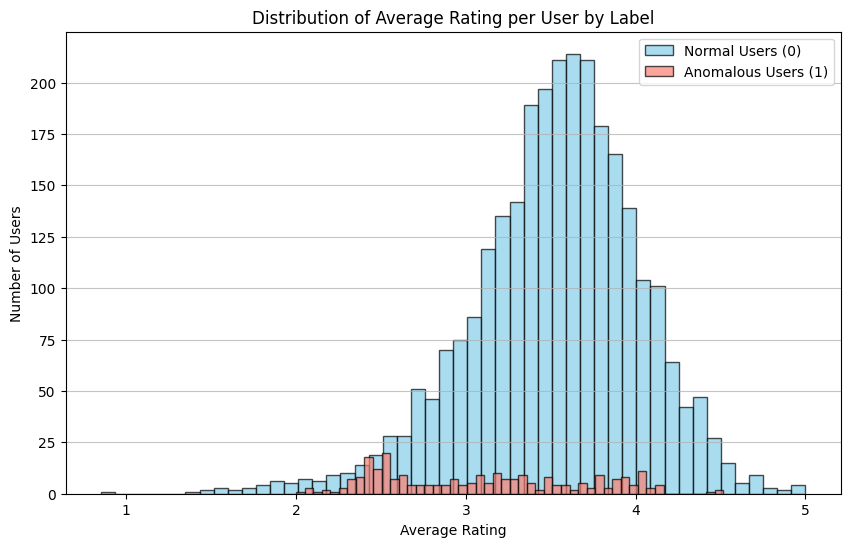

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average rating per user
user_avg_ratings = XX.groupby("user")["rating"].mean().reset_index()

# Merge with labels using the y array to be safe
df_y = pd.DataFrame(y, columns=["user", "label"])
user_avg_labeled = pd.merge(user_avg_ratings, df_y, on="user")

# Plot the distribution separated by labels
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    user_avg_labeled[user_avg_labeled["label"] == 0]["rating"],
    bins=50,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    user_avg_labeled[user_avg_labeled["label"] == 1]["rating"],
    bins=50,
    color="salmon",
    edgecolor="black",
    alpha=0.7,
    label="Anomalous Users (1)",
)

plt.title("Distribution of Average Rating per User by Label")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Average Rating per User by Label.png")

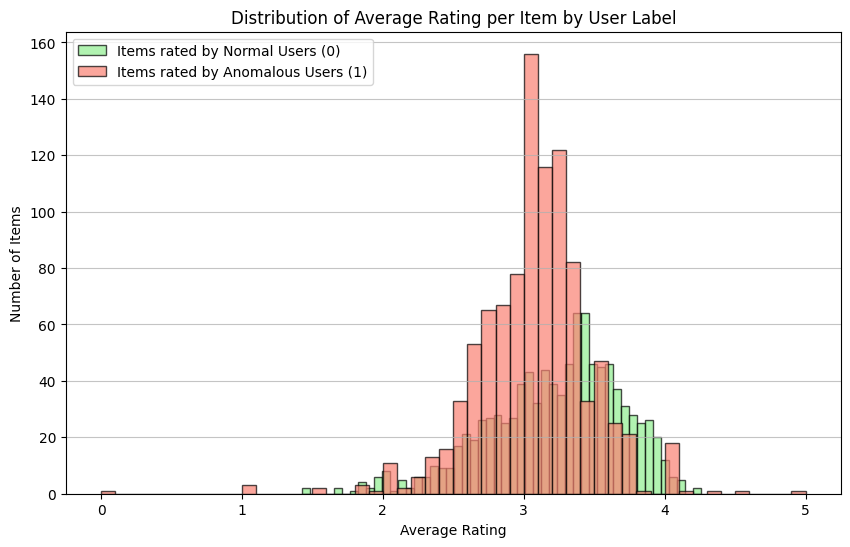

In [6]:
# Calculate average rating per item to compare between normal and anomalous users

# First, merge the labels into the main dataset based on user
XX_labeled = pd.merge(XX, df_y, on="user")

# Calculate average item ratings for normal users
item_avg_normal = XX_labeled[XX_labeled["label"] == 0].groupby("item")["rating"].mean()

# Calculate average item ratings for anomalous users
item_avg_anomalous = (
    XX_labeled[XX_labeled["label"] == 1].groupby("item")["rating"].mean()
)

# Plot the distribution separated by labels
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    item_avg_normal,
    bins=50,
    color="lightgreen",
    edgecolor="black",
    alpha=0.7,
    label="Items rated by Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    item_avg_anomalous,
    bins=50,
    color="salmon",
    edgecolor="black",
    alpha=0.7,
    label="Items rated by Anomalous Users (1)",
)

plt.title("Distribution of Average Rating per Item by User Label")
plt.xlabel("Average Rating")
plt.ylabel("Number of Items")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Average Rating per Item by User Label.png")

In [7]:
# Check if there are users who rate an item multiple times
duplicates = XX.duplicated(subset=["user", "item"], keep=False)
duplicate_ratings = XX[duplicates].sort_values(by=["user", "item"])

if not duplicate_ratings.empty:
    print(
        f"Found {len(duplicate_ratings)} instances of multiple ratings for the same user and item."
    )
    display(duplicate_ratings.head())
else:
    print(
        "No users rated the same item multiple times. Every user-item interaction is unique."
    )

No users rated the same item multiple times. Every user-item interaction is unique.


--- Sparsity Statistics ---
Minimum ratings by a user: 2
Maximum ratings by a user: 927
Average ratings per user: 156.68
Median ratings per user: 121.0
Overall matrix sparsity: 84.3009%



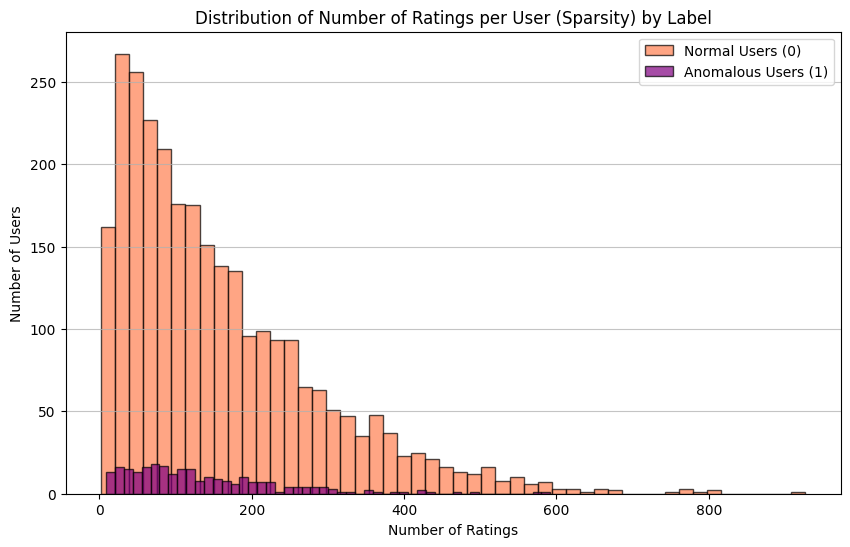

In [8]:
# Calculate the number of ratings each user made to understand sparsity
user_rating_counts = (
    XX_labeled.groupby(["user", "label"]).size().reset_index(name="count")
)

total_possible_ratings = len(XX["user"].unique()) * len(XX["item"].unique())
total_actual_ratings = len(XX)
overall_sparsity = 1.0 - (total_actual_ratings / total_possible_ratings)

# Print out some statistics
print("--- Sparsity Statistics ---")
print(f"Minimum ratings by a user: {user_rating_counts['count'].min()}")
print(f"Maximum ratings by a user: {user_rating_counts['count'].max()}")
print(f"Average ratings per user: {user_rating_counts['count'].mean():.2f}")
print(f"Median ratings per user: {user_rating_counts['count'].median()}")
print(f"Overall matrix sparsity: {overall_sparsity:.4%}\n")

# Plot the distribution of rating counts per user by label
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    user_rating_counts[user_rating_counts["label"] == 0]["count"],
    bins=50,
    color="coral",
    edgecolor="black",
    alpha=0.7,
    label="Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    user_rating_counts[user_rating_counts["label"] == 1]["count"],
    bins=50,
    color="purple",
    edgecolor="black",
    alpha=0.7,
    label="Anomalous Users (1)",
)

plt.title("Distribution of Number of Ratings per User (Sparsity) by Label")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Number of Ratings per User (Sparsity) by Label.png")

In [9]:
yy.rename(columns={0: "user", 1: "label"}, inplace=True)

In [10]:
yy.head(10)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
5,105,0
6,106,0
7,107,0
8,108,0
9,109,0


In [11]:
## Example with random scores

data_pred = np.load(infer_data_path)
X_pred = data_pred["X"]
n_users = len(np.unique(X_pred[:, 0]))

# Generate Random Anomaly Scores
np.random.seed(42)
y_score = np.random.uniform(0, 1, size=n_users)  # random float scores between 0 and 1

print(f"# of predictions:     {len(y_score)}")
print(f"Sample scores:        {y_score[:5]}")

## Save as submission.npz
np.savez("submission.npz", predictions=y_score)
print("\nsubmission.npz saved successfully!")

# of predictions:     1625
Sample scores:        [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]

submission.npz saved successfully!


# Student Response

TLDR:

- This is a dataset of user interactions.
- your job is to find anomalous users based on their current interactions.

### Solution 1: Autoencoders
- turn each user into a 1000-size vector
- train an autoencoder based on the userbase
- figure out whether people are weird based on some reconstruction loss function

In [12]:
NUM_ITEMS = 1000

# . convert interactions into a user-item matrix
# Rows = users (ordered by user_id), Cols = items 0..999, Values = rating (0 = no interaction)
df = pd.DataFrame(X, columns=["user", "item", "rating"])
df_by_user_item = df.pivot_table(
    index="user", columns="item", values="rating", fill_value=0
)

# Reindex columns to guarantee all 1000 items are present, even if some weren't rated
df_by_user_item = df_by_user_item.reindex(columns=range(NUM_ITEMS), fill_value=0)
df_by_user_item_norm = (
    df_by_user_item / 5.0
)  # Normalize ratings to [0, 1], make a copy for analysis

# user_ids in order, for aligning with labels
user_ids = df_by_user_item.index.to_numpy()
X_matrix = df_by_user_item.to_numpy(dtype=np.float32)  # shape: (n_users, 1000)

# Normalize ratings to [0, 1]
X_matrix = X_matrix / 5.0

In [13]:
# . align labels with user_item order
label_df = pd.DataFrame(y, columns=["user", "label"]).set_index("user")
labels = label_df.loc[user_ids, "label"].to_numpy()

# Train only on normal users (label == 0)ll
X_train = X_matrix[labels == 0]
# X_test = X_matrix  # score ALL users at inference

In [14]:
X_matrix.shape, X_train.shape
# X_matrix.shape, X_train.shape, X_test.shape, labels.shape

((3060, 1000), (2800, 1000))

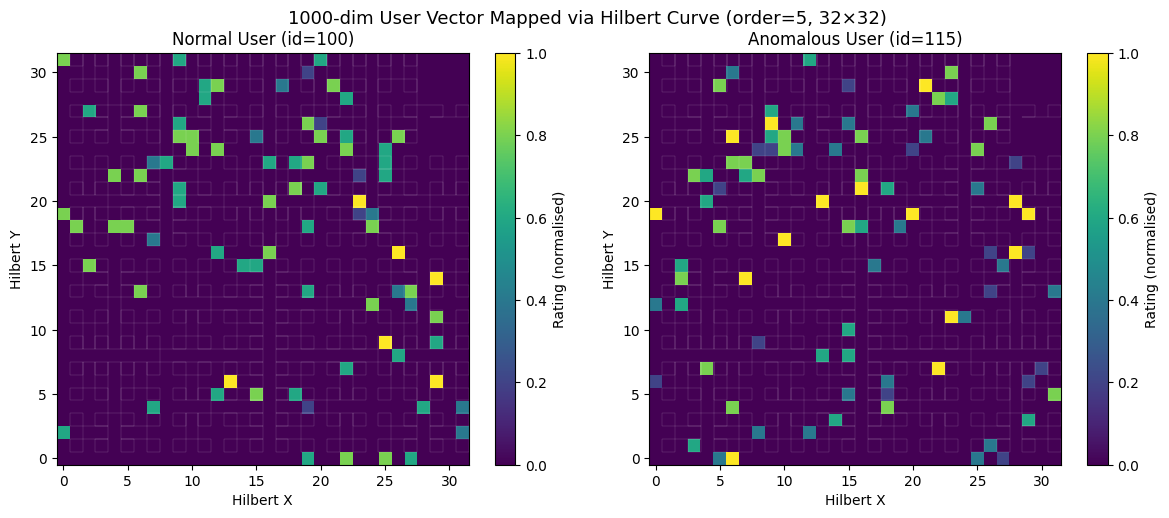

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def xy2d(n, x, y):
    """Convert (x, y) coords to Hilbert curve distance d, for an n x n grid (n must be power of 2)."""
    d = 0
    s = n // 2
    while s > 0:
        rx = 1 if (x & s) > 0 else 0
        ry = 1 if (y & s) > 0 else 0
        d += s * s * ((3 * rx) ^ ry)
        # Rotate quadrant
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        s //= 2
    return d

def d2xy(n, d):
    """Convert Hilbert curve distance d to (x, y) coords, for an n x n grid."""
    x = y = 0
    s = 1
    while s < n:
        rx = 1 if (d & 2) > 0 else 0
        ry = 1 if ((d & 1) ^ rx) == 0 else 0  # corrected: ry = (d & 1) XOR rx, inverted
        # Rotate
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        x += s * rx
        y += s * ry
        d //= 4
        s *= 2
    return x, y

def vector_to_hilbert_image(vec, order=5):
    """
    Map a 1D vector onto a 2D grid using a Hilbert space-filling curve.
    
    Parameters:
        vec: 1D array of length <= 2^(2*order) (e.g., 1000 for order=5 -> 32x32=1024)
        order: Hilbert curve order (grid will be 2^order x 2^order)
    
    Returns:
        2D numpy array of shape (2^order, 2^order)
    """
    n = 2 ** order  # grid side length
    total_cells = n * n
    
    # Pad vector to fill the grid (pad with 0)
    padded = np.zeros(total_cells, dtype=np.float32)
    padded[:len(vec)] = vec
    
    # Map each index along the Hilbert curve to its (x, y) position
    img = np.zeros((n, n), dtype=np.float32)
    for d in range(total_cells):
        x, y = d2xy(n, d)
        img[y, x] = padded[d]
    
    return img

# --- Visualise a sample normal user and a sample anomalous user ---
normal_indices = np.where(labels == 0)[0]
anomalous_indices = np.where(labels == 1)[0]

sample_normal = X_matrix[normal_indices[0]]
sample_anomalous = X_matrix[anomalous_indices[0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Also draw the Hilbert curve path as a line overlay
order = 5
n = 2 ** order
curve_points = [d2xy(n, d) for d in range(n * n)]
curve_x = [p[0] + 0.5 for p in curve_points[:1000]]  # only the 1000 used dims
curve_y = [p[1] + 0.5 for p in curve_points[:1000]]

for ax, vec, title in [
    (axes[0], sample_normal, f"Normal User (id={user_ids[normal_indices[0]]})"),
    (axes[1], sample_anomalous, f"Anomalous User (id={user_ids[anomalous_indices[0]]})")
]:
    img = vector_to_hilbert_image(vec, order=order)
    im = ax.imshow(img, cmap="viridis", origin="lower", interpolation="nearest")
    ax.plot(curve_x, curve_y, color="white", linewidth=0.3, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("Hilbert X")
    ax.set_ylabel("Hilbert Y")
    plt.colorbar(im, ax=ax, label="Rating (normalised)")

plt.suptitle("1000-dim User Vector Mapped via Hilbert Curve (order=5, 32×32)", fontsize=13)
plt.tight_layout()
plt.show()

Original vector (first 10 dims): [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


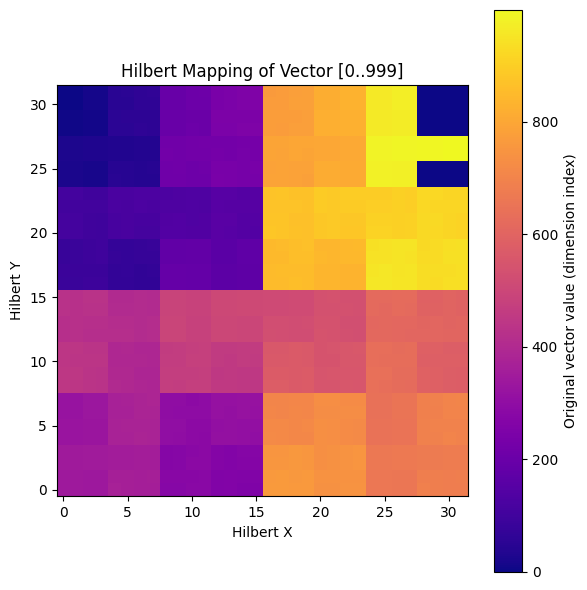

In [16]:
# Vector where each element equals its dimension index: [0, 1, 2, ..., 999]
dim_vector = np.arange(1000, dtype=np.float32)

print("Original vector (first 10 dims):", dim_vector[:10])

# Map to Hilbert image (32x32 since order=5 -> 2^(2*5)=1024 cells)
hilbert_dim_img = vector_to_hilbert_image(dim_vector, order=5)

plt.figure(figsize=(6, 6))
im = plt.imshow(hilbert_dim_img, cmap="plasma", origin="lower", interpolation="nearest")
plt.title("Hilbert Mapping of Vector [0..999]")
plt.xlabel("Hilbert X")
plt.ylabel("Hilbert Y")
plt.colorbar(im, label="Original vector value (dimension index)")
plt.tight_layout()
plt.show()

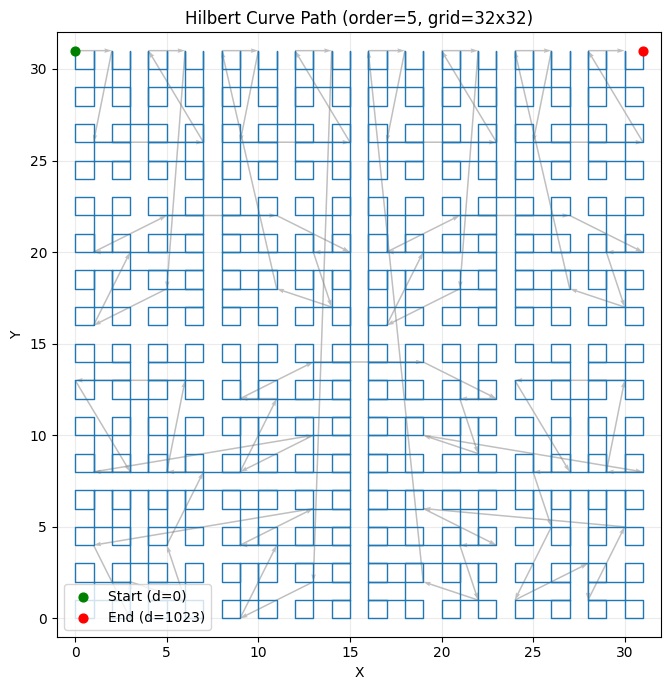

In [17]:
# Visualize the Hilbert curve path (order=5 -> 32x32 grid)
order = 5
n = 2**order
num_points = n * n

# Generate (x, y) coordinates along the curve
points = np.array([d2xy(n, d) for d in range(num_points)])
x, y = points[:, 0], points[:, 1]

plt.figure(figsize=(7, 7))
plt.plot(x, y, linewidth=1.0, color="tab:blue")
plt.scatter(x[0], y[0], color="green", s=40, label="Start (d=0)", zorder=3)
plt.scatter(x[-1], y[-1], color="red", s=40, label=f"End (d={num_points-1})", zorder=3)

# Optional direction arrows (sparse so the plot stays readable)
step = max(1, num_points // 80)
plt.quiver(
    x[:-step:step], y[:-step:step],
    x[step::step] - x[:-step:step], y[step::step] - y[:-step:step],
    angles="xy", scale_units="xy", scale=1, width=0.0025, alpha=0.5, color="gray"
)

plt.title(f"Hilbert Curve Path (order={order}, grid={n}x{n})")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-1, n)
plt.ylim(-1, n)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

# Build Hilbert-curve image input (N, 1, 32, 32) from the 1000-dim user vectors
HILBERT_ORDER = 5  # 2^5 = 32
GRID_SIZE = 2**HILBERT_ORDER  # 32
PADDED_DIM = GRID_SIZE * GRID_SIZE  # 1024

X_hilbert = np.stack(
    [vector_to_hilbert_image(v, order=HILBERT_ORDER) for v in X_matrix], axis=0
).astype(np.float32)
X_hilbert = X_hilbert[:, None, :, :]  # add channel dim -> (N, 1, 32, 32)

print("X_hilbert shape:", X_hilbert.shape)


class ResidualBlock(nn.Module):
    """Two conv layers with a skip connection. Uses SiLU (Swish) activation."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU(inplace=True)

        # 1x1 projection if channels change
        self.skip = (
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x):
        identity = self.skip(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.act(out + identity)
        return out


class Autoencoder(nn.Module):
    """
    Deeper Conv2D autoencoder with residual connections for Hilbert-mapped user vectors.
    Encoder downsamples 32x32 -> 24x24 at the bottleneck via AdaptiveAvgPool2d.
    Decoder upsamples 24x24 -> 32x32 via bilinear interpolation.
    Input:  (B, 1, 32, 32)
    Output: (B, 1, 32, 32)
    """

    def __init__(self, noise_factor=0.1):
        super().__init__()
        self.noise = nn.Dropout2d(p=noise_factor)

        self.encoder = nn.Sequential(
            ResidualBlock(1, 16),
            ResidualBlock(16, 32),
            ResidualBlock(32, 64),
            nn.AdaptiveAvgPool2d(24),       # 32x32 -> 24x24
            ResidualBlock(64, 32),
            ResidualBlock(32, 16),
            ResidualBlock(16, 4),            # bottleneck: (B, 4, 24, 24)
        )

        self.decoder = nn.Sequential(
            ResidualBlock(4, 16),
            ResidualBlock(16, 32),
            ResidualBlock(32, 64),
            nn.Upsample(size=(32, 32), mode='bilinear', align_corners=False),  # 24x24 -> 32x32
            ResidualBlock(64, 32),
            ResidualBlock(32, 16),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.noise(x)
        z = self.encoder(x)
        out = self.decoder(z)
        return out


# Optional: quick sanity check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(noise_factor=0.1).to(device)

test_batch = torch.tensor(X_hilbert[:8], dtype=torch.float32).to(device)
with torch.no_grad():
    recon = model(test_batch)

print("Input batch shape :", test_batch.shape)
print("Recon batch shape :", recon.shape)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters  : {total_params:,}")

X_hilbert shape: (3060, 1, 32, 32)
Input batch shape : torch.Size([8, 1, 32, 32])
Recon batch shape : torch.Size([8, 1, 32, 32])
Total parameters  : 226,205


Test model shapes

In [19]:
# Sanity check: verify data shapes through the model
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_model = Autoencoder(noise_factor=0.0).to(device)

# Test with a small batch from the actual data
sample = torch.tensor(X_hilbert[:4], dtype=torch.float32).to(device)
print(f"Input shape:   {sample.shape}")  # expect (4, 1, 32, 32)

# Trace through encoder and decoder separately
with torch.no_grad():
    noised = test_model.noise(sample)
    print(f"After noise:   {noised.shape}")

    encoded = test_model.encoder(noised)
    print(f"Encoded shape: {encoded.shape}")  # expect (4, 4, 24, 24) <- bottleneck

    decoded = test_model.decoder(encoded)
    print(f"Decoded shape: {decoded.shape}")  # expect (4, 1, 32, 32)

    full_out = test_model(sample)
    print(f"Full output:   {full_out.shape}")

# Verify bottleneck is 24x24
assert encoded.shape[2:] == (24, 24), f"Bottleneck shape mismatch! Got {encoded.shape[2:]}, expected (24, 24)"
print(f"\nBottleneck check passed: spatial dims are {encoded.shape[2:]}.")

# Verify input and output shapes match
assert sample.shape == full_out.shape, f"Shape mismatch! Input {sample.shape} vs Output {full_out.shape}"
print("Shape check passed: input and output shapes match.")

Input shape:   torch.Size([4, 1, 32, 32])
After noise:   torch.Size([4, 1, 32, 32])
Encoded shape: torch.Size([4, 4, 24, 24])
Decoded shape: torch.Size([4, 1, 32, 32])
Full output:   torch.Size([4, 1, 32, 32])

Bottleneck check passed: spatial dims are torch.Size([24, 24]).
Shape check passed: input and output shapes match.


Training stuff

In [20]:
from sklearn.model_selection import StratifiedKFold

# Apply K-Fold Cross Validation
N_SPLITS = 3
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"Set up {N_SPLITS}-Fold Cross Validation")

Set up 3-Fold Cross Validation


##### Training

In [21]:
def masked_mse_loss(recon, target):
    """
    Computes MSE only on elements where the target is > 0
    (i.e., only on items the user has actually rated).
    """
    mask = (target > 0).float()
    loss = ((recon - target) ** 2) * mask

    # Calculate mean specifically over the non-zero elements
    return loss.sum() / mask.sum().clamp(min=1)

In [22]:
# review devices available for training

if torch.cuda.is_available():
    print(f"CUDA Available: {torch.cuda.is_available()}")
    # Get the number of available GPUs
    gpu_count = torch.cuda.device_count()
    print(f"Number of GPUs available: {gpu_count}")

    # Iterate through and print the name of each GPU
    for i in range(gpu_count):
        print(f"GPU Name {i}: {torch.cuda.get_device_name(i)}")

    # Get the name of the *current* device (by default, device 0)
    print(f"Current device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA is not available on this system.")

CUDA Available: True
Number of GPUs available: 1
GPU Name 0: NVIDIA GeForce RTX 3050 Laptop GPU
Current device name: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
# device and model loading

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"Training device: {device} ({torch.cuda.get_device_name(device)})")
else:
    print(f"Training device: {device}")

model = Autoencoder().to(device)


# Model hyperparameters and settings

LEARNING_RATE = 1e-3
NOISE_FACTOR = 0.1
EPOCHS = 150


# Use our newly defined masked MSE logic
criterion = masked_mse_loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

best_val_auc = -np.inf
best_state = None
best_val_loss = np.inf
best_epoch = 0
patience_counter = 0

# Unnamed/missing constants
BATCH_SIZE = 64
CV_MIN_DELTA = 1e-4
CV_PATIENCE = 15
ENABLE_EARLY_STOPPING = True
TRAIN_ON_NORMAL_ONLY = True

In [ ]:
import os
import copy
import datetime
import torch
import numpy as np
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base_run_dir = os.path.join(WEIGHTS_DIR_LARRY, run_timestamp)


def train_fold(fold, train_idx, val_idx):
    print(f"\n{'='*20} Starting Fold {fold+1}/{N_SPLITS} {'='*20}")

    # Restrict training to normal users if flag is set
    train_normal_idx = (
        train_idx[labels[train_idx] == 0] if TRAIN_ON_NORMAL_ONLY else train_idx
    )

    # Use X_hilbert (4D tensor) instead of X_matrix (2D tensor) since Conv2D expects (B, C, H, W)
    X_train_fold = X_hilbert[train_normal_idx]
    X_val_fold = X_hilbert[val_idx]
    y_val_fold = labels[val_idx]

    # Full training set (normal + anomalous) for computing training AUC
    X_train_all = X_hilbert[train_idx]
    y_train_fold = labels[train_idx]

    fit_tensor = torch.tensor(X_train_fold, dtype=torch.float32).to(device)
    val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)
    train_all_tensor = torch.tensor(X_train_all, dtype=torch.float32).to(device)

    fit_loader = DataLoader(
        TensorDataset(fit_tensor), batch_size=BATCH_SIZE, shuffle=True
    )

    fold_model = Autoencoder(noise_factor=NOISE_FACTOR).to(device)
    fold_optimizer = torch.optim.AdamW(fold_model.parameters(), lr=LEARNING_RATE)

    best_val_auc = -np.inf
    best_state = None
    best_val_loss = np.inf
    patience_counter = 0
    best_epoch = 0

    run_dir = os.path.join(base_run_dir, f"fold_{fold+1}")
    os.makedirs(run_dir, exist_ok=True)

    for epoch in range(EPOCHS):
        # --- Training Phase ---
        fold_model.train()
        running_loss = 0.0
        for (batch,) in fit_loader:
            recon = fold_model(batch)
            loss = criterion(recon, batch)

            fold_optimizer.zero_grad()
            loss.backward()
            fold_optimizer.step()

            running_loss += loss.item() * batch.size(0)

        train_loss = running_loss / len(fit_tensor)

        # --- Validation Phase ---
        fold_model.eval()
        with torch.no_grad():
            # Compute training AUC on all training users (normal + anomalous)
            train_all_recon = fold_model(train_all_tensor)
            train_mask = (train_all_tensor > 0).float()
            train_squared_errors = ((train_all_tensor - train_all_recon) ** 2) * train_mask
            train_scores = (
                (
                    train_squared_errors.sum(dim=(1, 2, 3))
                    / train_mask.sum(dim=(1, 2, 3)).clamp(min=1)
                )
                .cpu()
                .numpy()
            )

            # Compute validation metrics
            val_recon = fold_model(val_tensor)
            val_mask = (val_tensor > 0).float()
            squared_errors = ((val_tensor - val_recon) ** 2) * val_mask

            # Sum over dim=(1, 2, 3) for the 4D validation tensor
            val_scores = (
                (
                    squared_errors.sum(dim=(1, 2, 3))
                    / val_mask.sum(dim=(1, 2, 3)).clamp(min=1)
                )
                .cpu()
                .numpy()
            )
            val_loss = (squared_errors.sum() / val_mask.sum().clamp(min=1)).item()

        # Calculate AUCs if possible
        if len(np.unique(y_train_fold)) > 1:
            train_auc = roc_auc_score(y_train_fold, train_scores)
        else:
            train_auc = 0.5

        if len(np.unique(y_val_fold)) > 1:
            val_auc = roc_auc_score(y_val_fold, val_scores)
        else:
            val_auc = 0.5

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            # Avoiding copy.deepcopy on state_dict to prevent torch._subclasses AttributeError
            best_state = {
                k: v.cpu().clone() for k, v in fold_model.state_dict().items()
            }
            best_epoch = epoch + 1

        if best_val_loss - val_loss > CV_MIN_DELTA:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:>3}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}"
            )

        if ENABLE_EARLY_STOPPING and patience_counter >= CV_PATIENCE:
            print(
                f"Early stop triggered at epoch {epoch+1} (best val loss: {best_val_loss:.6f})"
            )
            break

    print(
        f"Fold {fold+1} Complete. Best Validation AUC: {best_val_auc:.4f} at Epoch {best_epoch}"
    )

    if best_state is not None:
        best_save_dir = os.path.join(run_dir, "best_state")
        os.makedirs(best_save_dir, exist_ok=True)
        best_chkpt_path = os.path.join(best_save_dir, f"best_model_ep{best_epoch}.pth")
        torch.save(best_state, best_chkpt_path)

    return best_val_auc, best_state


fold_aucs = []
best_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_matrix, labels)):
    best_auc, best_model_state = train_fold(fold, train_idx, val_idx)
    fold_aucs.append(best_auc)
    best_models.append(best_model_state)

print("\n===== Cross Validation Summary =====")
for i, auc in enumerate(fold_aucs):
    print(f"Fold {i+1} AUC: {auc:.4f}")
print(f"Average AUC: {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")

# Select the best model across all folds for doing inference later on
best_fold_idx = np.argmax(fold_aucs)
print(f"\nLoading best model from Fold {best_fold_idx+1} for inference")
model.load_state_dict(best_models[best_fold_idx])

save config

In [25]:
import json
import os
import datetime

# Create a comprehensive configuration dictionary
training_config = {
    "model_architecture": {
        "noise_factor": NOISE_FACTOR
    },
    "training_hyperparameters": {
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "cv_min_delta": CV_MIN_DELTA,
        "cv_patience": CV_PATIENCE,
        "enable_early_stopping": ENABLE_EARLY_STOPPING,
        "train_on_normal_only": TRAIN_ON_NORMAL_ONLY
    },
    "metadata": {
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
}

# Define save path
save_dir = WEIGHTS_DIR_LARRY
os.makedirs(save_dir, exist_ok=True)
timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
full_config_path = os.path.join(save_dir, f"full_training_config_{timestamp_str}.json")

# Save to JSON
with open(full_config_path, "w") as f:
    json.dump(training_config, f, indent=4)
    
print(f"Full model and training configuration saved to: {full_config_path}")

Full model and training configuration saved to: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/weights\full_training_config_20260327_152336.json


# Inference: Anomaly Detection on Test Data

In [26]:
print("Processing infer_data_path...")

# 1. Extract the raw interaction array
X_first = infer_data__test["X"]

# 2. Convert to DataFrame and pivot to user-item matrix
df_first = pd.DataFrame(X_first, columns=["user", "item", "rating"])
df_first_pivot = df_first.pivot_table(
    index="user", columns="item", values="rating", fill_value=0
)

# 3. Reindex to ensure all 1000 items are present
df_first_pivot = df_first_pivot.reindex(columns=range(NUM_ITEMS), fill_value=0)

# 4. Extract user IDs and normalize the ratings just like during training
first_user_ids = df_first_pivot.index.to_numpy(dtype=int)
X_first_matrix = df_first_pivot.to_numpy(dtype=np.float32) / 5.0

# 5. Convert to 4D Hilbert Tensors since the Inference model expects (B, 1, 32, 32)
HILBERT_ORDER = 5
X_first_hilbert = np.stack(
    [vector_to_hilbert_image(v, order=HILBERT_ORDER) for v in X_first_matrix], axis=0
).astype(np.float32)
X_first_hilbert = X_first_hilbert[:, None, :, :]  # add channel dim -> (N, 1, 32, 32)

# Convert to PyTorch Tensor
first_tensor = torch.tensor(X_first_hilbert, dtype=torch.float32).to(device)

df_first_pivot.head()


Processing infer_data_path...


item,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
user,,,,,,,,,,,,,,,,,,,,,
5500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5501,3.0,2.0,0.0,3.0,2.0,4.0,4.0,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5502,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5503,4.0,3.0,0.0,0.0,0.0,3.0,0.0,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5504,2.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# 6. Run Inference (Using the same masked approach as Validation)
model.eval()
with torch.no_grad():
    first_recon = model(first_tensor)
    
    # We only care about anomalies on items the user actually interacted with (>0)
    first_mask = (first_tensor > 0).float()
    squared_errors = ((first_tensor - first_recon) ** 2) * first_mask
    
    # Compute the average reconstruction error strictly over the non-zero ratings
    # Sum over dim=(1, 2, 3) for the 4D validation tensor
    first_anomaly_scores = (
        (squared_errors.sum(dim=(1, 2, 3)) / first_mask.sum(dim=(1, 2, 3)).clamp(min=1)).cpu().numpy()
    )

# Normalize scores to [0, 1] to avoid warnings during submission
scores_min = first_anomaly_scores.min()
scores_max = first_anomaly_scores.max()
if scores_max > scores_min: # Avoid division by zero
    first_anomaly_scores = (first_anomaly_scores - scores_min) / (scores_max - scores_min)

# 7. Create a DataFrame structured exactly like "y" (columns "user", "label")
first_predictions_df = pd.DataFrame({
    "user": first_user_ids,
    "label": first_anomaly_scores  # Our continuous anomaly scores
})

print(f"Successfully generated dataset with shape: {first_predictions_df.shape}")
first_predictions_df.head(10)

Successfully generated dataset with shape: (1625, 2)


,user,label
0,5500,0.117902
1,5501,0.133837
2,5502,0.064792
3,5503,0.174540
4,5504,0.141216
5,5505,0.651723
6,5506,0.198772
7,5507,0.151341
8,5508,0.177414
9,5509,0.060729


In [28]:
# Range of values for labels
print("Label min:", first_predictions_df["label"].min())
print("Label max:", first_predictions_df["label"].max())
print("Unique label values:", np.sort(first_predictions_df["label"].unique()))

Label min: 0.0
Label max: 1.0
Unique label values: [0.         0.0036991  0.02307443 ... 0.9298094  0.9405149  1.        ]


In [29]:
from sklearn.metrics import f1_score, precision_recall_curve

# Re-create the folds to get the validation indices of the best fold
cv_splits = list(skf.split(X_matrix, labels))
_, best_val_idx = cv_splits[best_fold_idx]

# Validation subset from the best fold indices
X_val_fold = X_hilbert[best_val_idx]
y_val_fold = labels[best_val_idx]

# Compute anomaly scores (masked reconstruction error)
val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    val_recon = model(val_tensor)
    val_mask = (val_tensor > 0).float()
    squared_errors = ((val_tensor - val_recon) ** 2) * val_mask
    val_scores = (
        squared_errors.sum(dim=(1, 2, 3)) / val_mask.sum(dim=(1, 2, 3)).clamp(min=1)
    ).cpu().numpy()

# Find threshold that maximizes F1 on this validation set
precision, recall, thresholds = precision_recall_curve(y_val_fold, val_scores)
f1_values = 2 * precision * recall / (precision + recall + 1e-12)

# precision/recall has one extra point, so align with thresholds
best_idx = np.argmax(f1_values[:-1])
best_threshold = thresholds[best_idx]

y_val_pred = (val_scores >= best_threshold).astype(int)
val_f1 = f1_score(y_val_fold, y_val_pred)

print(f"Best Fold: {best_fold_idx + 1}")
print(f"Validation F1 score: {val_f1:.4f}")
print(f"Best threshold: {best_threshold:.6f}")

Best Fold: 3
Validation F1 score: 0.4545
Best threshold: 0.089231


In [30]:
import datetime
import zipfile

# Extract anomaly scores as a 1D numpy array (scoring program expects only scores, not user IDs)
y_score_predictions = first_predictions_df["label"].to_numpy()

# 1. Save the predictions to a .npz file (Codabench submission format)
# The key MUST be named 'predictions'
npz_filename = "submission.npz"
submission_filepath = os.path.join(RESULTS_DIR_LARRY, npz_filename)
np.savez(submission_filepath, predictions=y_score_predictions)
print(f"Successfully saved {len(y_score_predictions)} predictions to '{submission_filepath}'")

# 2. Zip the file for Codabench upload
timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_basename = f"submission_{timestamp_str}.zip"
zip_filepath = os.path.join(RESULTS_DIR_LARRY, zip_basename)

# We must write it inside the zip. Naming the internal file exactly "submission.npz" to be safe.
with zipfile.ZipFile(zip_filepath, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(submission_filepath, arcname=npz_filename)

print(f"Successfully zipped to '{zip_filepath}' for Codabench submission!")
print(f"Array shape: {y_score_predictions.shape}")

Successfully saved 1625 predictions to 'c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\submission.npz'
Successfully zipped to 'c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\submission_20260327_152354.zip' for Codabench submission!
Array shape: (1625,)
